In [21]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

import sys
sys.path.insert(0, '/cosma/home/dp004/dc-zhan5')
import MyHaloPS as ps
import importlib
importlib.reload(ps)
import pickle

from scipy.special import sici
from scipy.integrate import quad

In [2]:
import seaborn as sns
palette_tab10 = sns.color_palette("colorblind", 10)

In [3]:
plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"
plt.rc("font", family="STIXGeneral", size=18)
plt.rcParams["mathtext.fontset"] = "stix"
plt.rcParams['figure.figsize'] = (2*10/3, 4)
plt.rcParams["legend.frameon"] = False


plt.rcParams["xtick.major.size"] = 5
plt.rcParams["ytick.major.size"] = 5
plt.rcParams["ytick.minor.visible"] = True
plt.rcParams["xtick.minor.visible"] = True
plt.rcParams["xtick.top"] = True
plt.rcParams["ytick.right"] = True
plt.rcParams["lines.linewidth"] = 2

In [4]:
logMmin = 13.0
logMmax = 13.1

odir1 = f"/cosma/home/dp004/dc-zhan5/paper1/ps_data/snap40/mvir/weighted_nfw/logM{logMmin}-{logMmax}"
fname1 = f"{odir1}/sat_nfw_sum/weighted_c4_rvir0.5_n50/w10_in_rs.pickle"
with open(fname1, "rb") as f:
    Pk_mean110 = pickle.load(f)
    Pk13_sum = pickle.load(f)
fname2 = f"{odir1}/sat_nfw/weighted_c4_rvir0.5_n50/w10_in_rs.pickle"
with open(fname2, "rb") as f:
    Pk_mean110 = pickle.load(f)
    Pk13_gal = pickle.load(f)

In [5]:
logMmin = 13.0
logMmax = 13.1

odir1 = f"/cosma/home/dp004/dc-zhan5/paper1/ps_data/snap40/mvir/weighted_nfw/logM{logMmin}-{logMmax}"
fname1 = f"{odir1}/sat_nfw_sum/weighted_c4_rvir0.5_n10/w10_w20_in_rs.pickle"
with open(fname1, "rb") as f:
    Pk_mean110 = pickle.load(f)
    Pk13_sum1 = pickle.load(f)
fname2 = f"{odir1}/sat_nfw/weighted_c4_rvir0.5_n10/w10_w20_in_rs.pickle"
with open(fname2, "rb") as f:
    Pk_mean110 = pickle.load(f)
    Pk13_gal1 = pickle.load(f)

In [6]:
logks_tng = np.log10(Pk13_sum["k"])

In [11]:
def compute_uk2(Pk_gal10, Pk_sum10):
    ks_tng = Pk_gal10["k"]


    tot = (Pk_gal10["power"]-(Pk_sum10["power"]-Pk_sum10.attrs["shotnoise"]))
    
    shot_gal = Pk_gal10.attrs["shotnoise"]
    shot_halo = Pk_sum10.attrs["shotnoise"]
    uk2 = (tot - shot_gal)/(shot_halo - shot_gal)
    return uk2

In [12]:
uk2_13 = compute_uk2(Pk13_gal, Pk13_sum)

In [13]:
uk2_13_1 = compute_uk2(Pk13_gal1, Pk13_sum1)

In [14]:
def nfw_profile(r, rho0, rs):
    return rho0 / ((r / rs) * (1 + r / rs)**2)

def rho_s(mvir, r_s, c):
    rhos = (mvir/(4*np.pi*r_s**3))*(np.log(1+c) - c/(1+c))**-1
    return rhos

In [15]:
def weight_func(x):
    logx = np.log10(x)
    # if (x > 0.2) & (x < 0.8):
    #     logy = 0.75*(logx-3.1)**2 -0.65
    if x < 0.125:
        y = 15
        
    else:
        #logy = 0
        y = 1

    # if (x > 0.2) & (x < 0.8):
    #     logy = 0.75*(logx-3.1)**2 -0.65
    #     y = 10**logy
    # else:
    #     y = 1
    #logy = np.zeros(len(bin_centers))
    

    #logy = 0.7*(logx-3.2)**2 -0.7
    #mask = x > 100
    return y

In [16]:
def combined_profile(r, rho0, rs):
    return nfw_profile(r, rho0, rs)*weight_func(r)

In [17]:
def combined_numerical_ft(k_values, rho0, rs, rvir, rmax):

    def integrand_func(r):
        integrand = 4*np.pi* r**2 * combined_profile(r, rho0, rs) * np.sin(k * r) / (k * r)
        return integrand

    def integrand_norm(r):
        integrand = 4*np.pi* r**2 * combined_profile(r, rho0, rs)
        return integrand

    norm_factor = quad(integrand_norm , 0, rmax, limit=300)[0]
    results = []
    for k in k_values:
        result = quad(integrand_func , 0, rmax, limit=300)[0]
        results.append(result)

    return np.array(results)/norm_factor

In [18]:
logks = np.arange(-1.5,2,0.01)
ks = 10**logks
c=4
rvir=0.5
rs = rvir/c
rho0 = rho_s(10**13, rs, c)
uk_numerical = combined_numerical_ft(ks, rho0, rs,rvir, rmax=0.5)

In [19]:
logks = np.arange(-1.5,2,0.01)
ks = 10**logks
c=4
rvir=0.5
rs = rvir/c
rho0 = rho_s(10**13, rs, c)
uk2 = combined_numerical_ft(ks, rho0, rs,rvir, rmax=0.5)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


Text(0, 0.5, '$U(k)^2$')

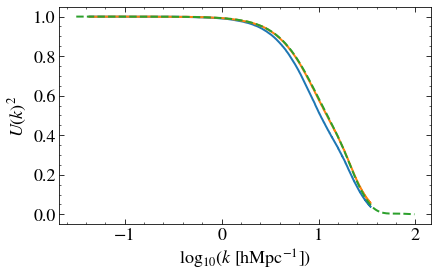

In [20]:
plt.plot(logks_tng, uk2_13, label="SFR weighting")
plt.plot(logks_tng, uk2_13_1, label="Equal weighting")
#plt.plot(logks, uk_nfw**2, label="NFW Ishiyama, logM13, c=4, rvir=0.5cMpc/h")


plt.plot(logks, uk_numerical**2, label="$c=4, r_{\mathrm{max}}=$1 cMpc/h", linestyle="dashed")

#plt.plot(logks, uk_numerical2**2, label="$c=50, r_{\mathrm{max}}=$1.5 cMpc/h", linestyle="dashed")
#plt.plot(logks, uk_nfw1**2, label="NFW Ishiyama, logM13")
#plt.legend()

plt.xlabel(r"$\mathrm{log}_{10}(k\ \mathrm{[h Mpc^{-1}]})$")
plt.ylabel("$U(k)^2$")
